In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4

TRAIN_DIR = r"E:\ec300\Oral cancer Dataset 2.0\train"
VALID_DIR = r"E:\ec300\Oral cancer Dataset 2.0\valid"


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)


Found 650 images belonging to 2 classes.


In [4]:
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.5   # split valid folder into 50% + 50%
)

val_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=False
)

test_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 150 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [5]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [6]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("oral_cancer_vgg16_best.h5",
                    monitor="val_accuracy",
                    save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
35/41 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5172 - loss: 0.7349

e:\anaconda3\envs\myenv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5188 - loss: 0.7324

41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.5338 - loss: 0.7160 - val_accuracy: 0.6133 - val_loss: 0.6618
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5866 - loss: 0.6795

41/41 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.5785 - loss: 0.6929 - val_accuracy: 0.6667 - val_loss: 0.6415
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5867 - loss: 0.6737

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7077 - loss: 0.5600 - val_accuracy: 0.8067 - val_loss: 0.5291
Epoch 12/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7575 - loss: 0.5253

41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7385 - loss: 0.5340 - val_accuracy: 0.8200 - val_loss: 0.5203
Epoch 13/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7846 - loss: 0.5285 - val_accuracy: 0.7800 - val_loss: 0.5147
Epoch 14/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7479 - loss: 0.5276 

41/41 ━━━━━━━━━━━━━━━━━━━━ 814s 20s/step - accuracy: 0.7523 - loss: 0.5152 - val_accuracy: 0.8267 - val_loss: 0.5041
Epoch 15/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7662 - loss: 0.5057 - val_accuracy: 0.8000 - val_loss: 0.4982
Epoch 16/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7569 - loss: 0.5161 - val_accuracy: 0.7933 - val_loss: 0.4933
Epoch 17/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2753s 69s/step - accuracy: 0.7800 - loss: 0.4996 - val_accuracy: 0.8200 - val_loss: 0.4829
Epoch 18/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8091 - loss: 0.4958

41/41 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7908 - loss: 0.4898 - val_accuracy: 0.8333 - val_loss: 0.4717
Epoch 19/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7437 - loss: 0.5190

41/41 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7692 - loss: 0.4976 - val_accuracy: 0.8467 - val_loss: 0.4716
Epoch 20/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 5931s 148s/step - accuracy: 0.7708 - loss: 0.4872 - val_accuracy: 0.8467 - val_loss: 0.4667
Epoch 21/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8077 - loss: 0.4582 - val_accuracy: 0.8333 - val_loss: 0.4611
Epoch 22/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8292 - loss: 0.4436 - val_accuracy: 0.8400 - val_loss: 0.4524
Epoch 23/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8031 - loss: 0.4635 - val_accuracy: 0.8333 - val_loss: 0.4467
Epoch 24/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7954 - loss: 0.4661 - val_accuracy: 0.8000 - val_loss: 0.4536
Epoch 25/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8138 - loss: 0.4577 - val_accuracy: 0.8467 - val_loss: 0.4369
Epoch 26/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8138 - loss: 0.4375 - val_accuracy: 0.8467 - val_loss:

In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print("Final Test Accuracy:", test_acc)


10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8000 - loss: 0.4749
Final Test Accuracy: 0.800000011920929


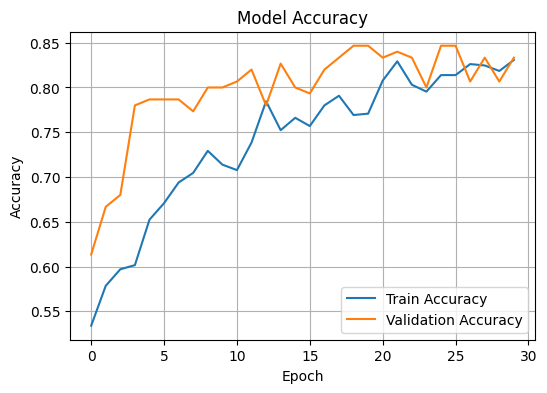

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


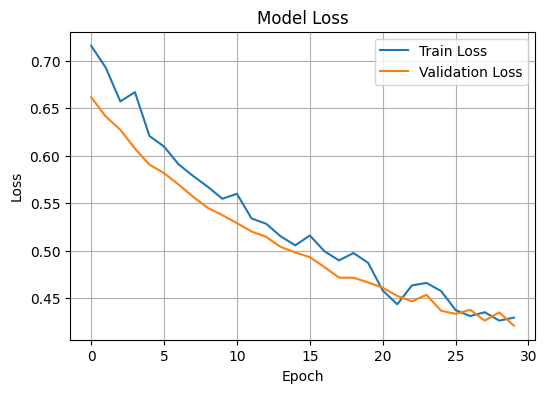

In [9]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
